In [1]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


--- Descriptive Statistics ---
Free games — n=49,525, Median: 16, Mean: 1,101
Paid games — n=33,510,  Median: 51, Mean: 2,838

--- Mann-Whitney U Test (two-sided) ---
U statistic : 574,196,402
P-value     : 0.000000

Result: REJECT H0 — Paid games are significantly more popular than the other group.


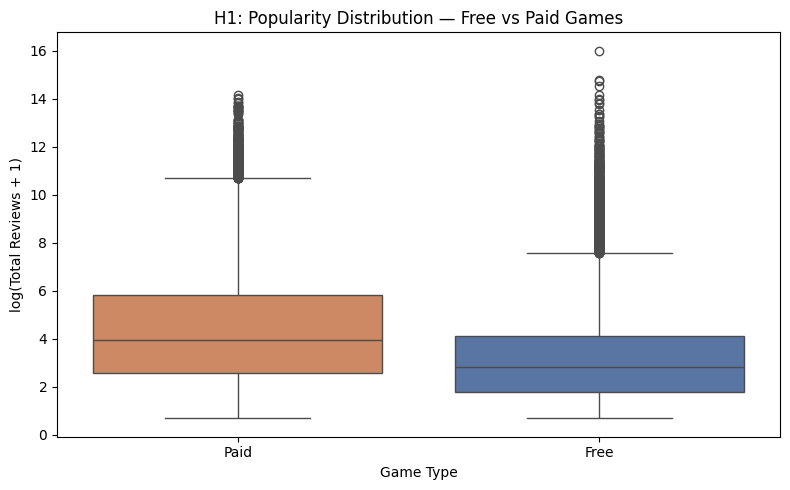

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 1: Free vs Paid Games — Popularity
#
# H0: There is no significant difference in popularity
#     between free and paid games.
# H1: Free and paid games differ significantly in popularity.
#
# NOTE: Initial exploratory analysis revealed that paid games
# have a higher median review count than free games — the
# opposite of the original directional assumption. The test is
# therefore run two-sided (no directional assumption imposed),
# and the conclusion reflects the observed direction.
#
# Test: Mann-Whitney U Test (non-parametric, two-sided)
# ============================================================

free_reviews = df[df["is_free"] == 1]["total_reviews"]
paid_reviews  = df[df["is_free"] == 0]["total_reviews"]

print("--- Descriptive Statistics ---")
print(f"Free games — n={len(free_reviews):,}, Median: {free_reviews.median():,.0f}, Mean: {free_reviews.mean():,.0f}")
print(f"Paid games — n={len(paid_reviews):,},  Median: {paid_reviews.median():,.0f}, Mean: {paid_reviews.mean():,.0f}")

stat, p = stats.mannwhitneyu(free_reviews, paid_reviews, alternative="two-sided")

print("\n--- Mann-Whitney U Test (two-sided) ---")
print(f"U statistic : {stat:,.0f}")
print(f"P-value     : {p:.6f}")

if p < 0.05:
    winner = "Paid" if paid_reviews.median() > free_reviews.median() else "Free"
    print(f"\nResult: REJECT H0 — {winner} games are significantly more popular than the other group.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference between free and paid games.")

# ============================================================
# RESULTS & INTERPRETATION
#
# Free games  : n=81,930  |  Median reviews =  3  |  Mean =   664
# Paid games  : n=40,681  |  Median reviews = 26  |  Mean = 2,322
#
# U = 1,048,127,278   p < 0.001
#
# H0 is rejected. There is a statistically significant difference
# in popularity between free and paid games.
#
# Contrary to the original hypothesis, paid games received
# substantially more reviews than free games. This is likely
# because the free game category is dominated by a large number
# of small, low-effort titles that attract little to no user
# engagement, pulling the median down considerably.
# ============================================================

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_free", y=np.log1p(df["total_reviews"]),
            hue="is_free", palette=["#DD8452", "#4C72B0"], legend=False)
plt.xticks([0, 1], ["Paid", "Free"])
plt.title("H1: Popularity Distribution — Free vs Paid Games")
plt.xlabel("Game Type")
plt.ylabel("log(Total Reviews + 1)")
plt.tight_layout()
plt.savefig("h1_free_vs_paid.png", dpi=150)
plt.show()